In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv('/content/loan_approval_dataset.csv')

In [4]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [6]:
df.shape

(4269, 13)

In [7]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [8]:
#remove extra space
df.columns = df.columns.str.strip()

In [9]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [11]:
df.dtypes

,0
loan_id,int64
no_of_dependents,int64
education,object
self_employed,object
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64


In [12]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [13]:
#target variable
df['loan_status'].value_counts()

,count
loan_status,
Approved,2656
Rejected,1613


In [15]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.dtypes

,0
loan_id,int64
no_of_dependents,int64
education,object
self_employed,object
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64


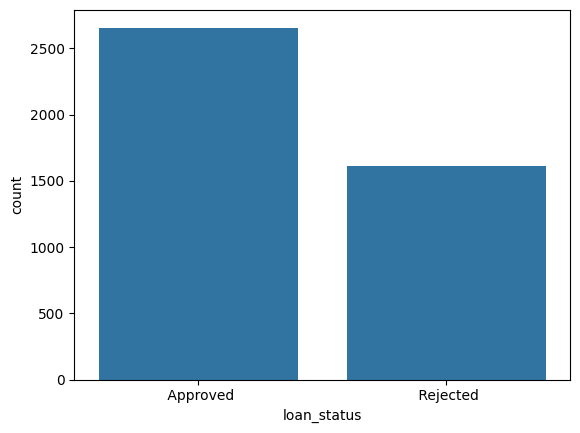

In [19]:
#EDA (loan status)
sns.countplot(x='loan_status',data=df)
plt.show()

The number of loan application approved are more than the rejected application


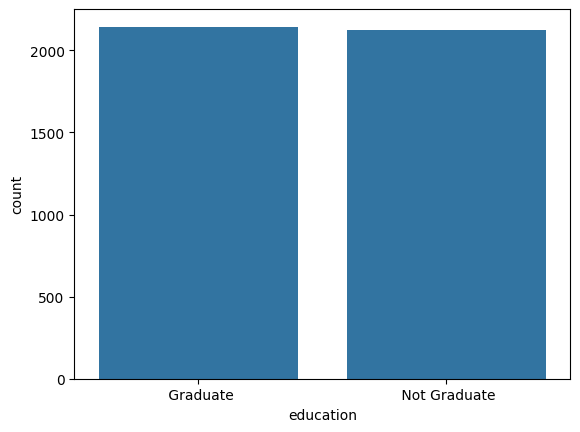

In [20]:
sns.countplot(x='education',data=df)
plt.show()

Graduate and Not Graduate count are similar

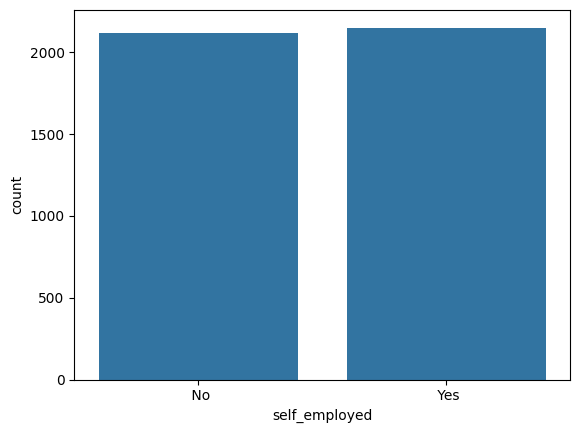

In [21]:
sns.countplot(x='self_employed',data=df)
plt.show()

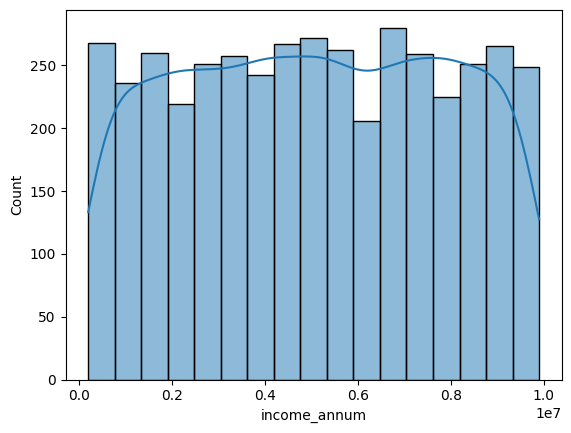

In [22]:
sns.histplot(df['income_annum'],kde=True)
plt.show()

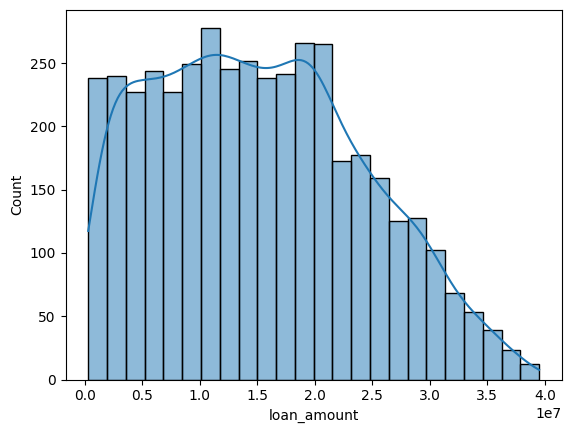

In [23]:
sns.histplot(df['loan_amount'],kde=True)
plt.show()

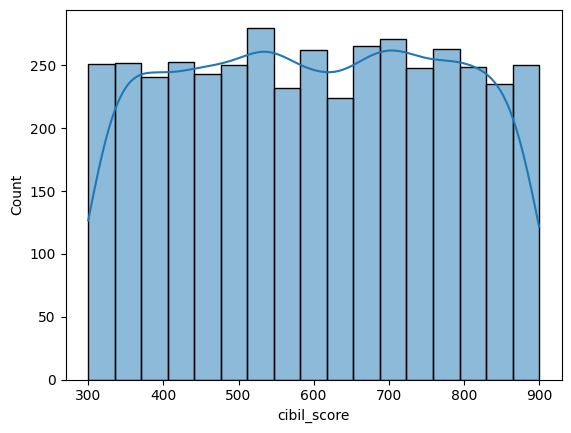

In [24]:
sns.histplot(df['cibil_score'],kde=True)
plt.show()

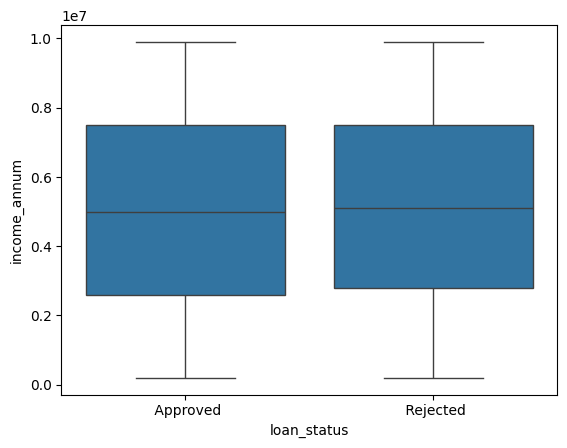

In [25]:
#income vs loan status
sns.boxplot(x='loan_status',y='income_annum',data=df)
plt.show()

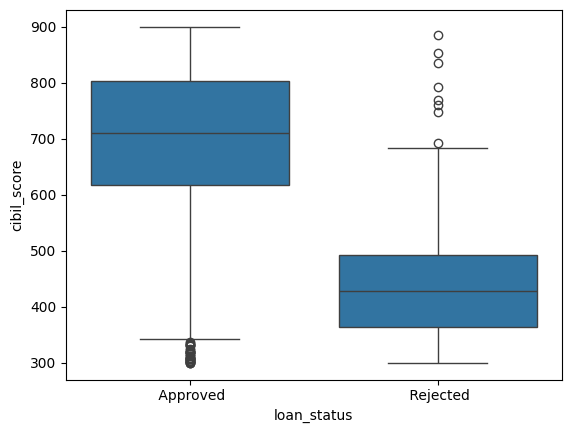

In [26]:
sns.boxplot(x='loan_status',y='cibil_score',data=df)
plt.show()

In [27]:
#encoding
le = LabelEncoder()
df['loan_status'] = le.fit_transform(df['loan_status'])
df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])

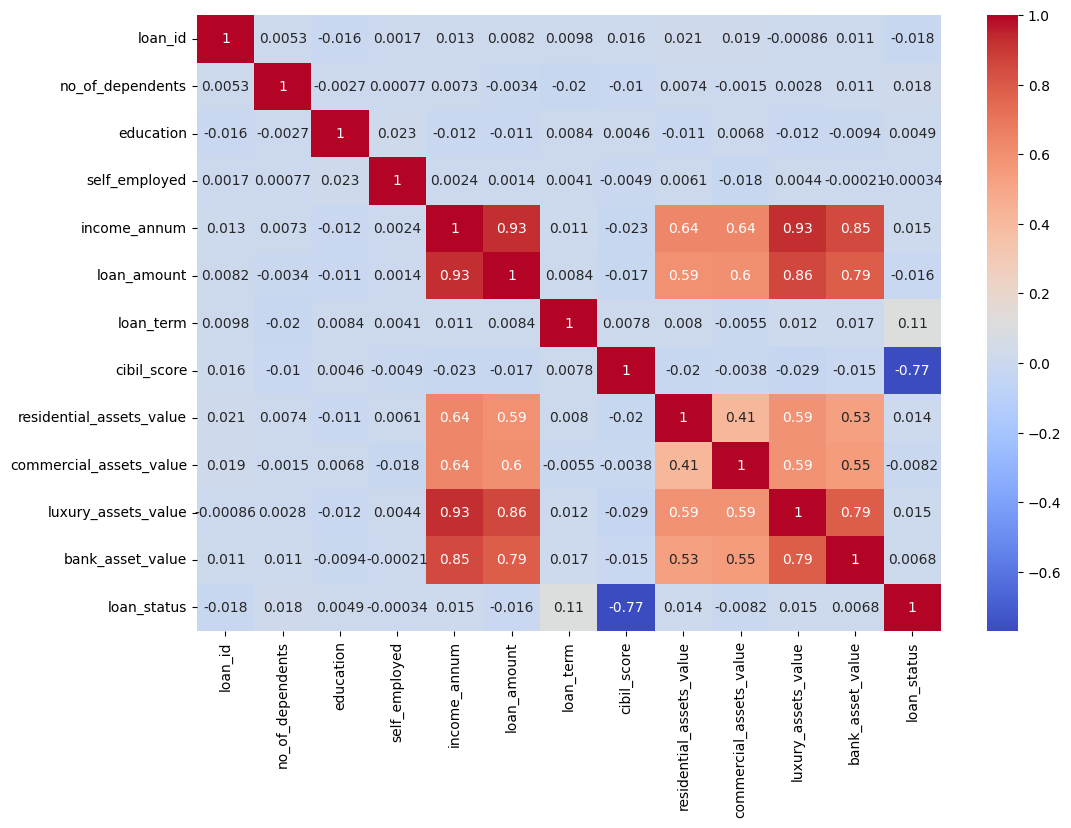

In [28]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

The correlation heatmap shows that the CIBIL score has the strongest relationship with loan status, making it the most important factor in loan approval prediction. Financial features such as annual income, loan amount, and asset values are highly correlated with each other, indicating that applicants with higher income generally have higher assets and apply for larger loans. On the other hand, features like education, self-employment, and number of dependents have very little impact on loan approval compared to financial and credit-related factors.

In [29]:
X = df.drop('loan_status',axis=1)
Y = df['loan_status']

Train test split

In [30]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [31]:
#scaling
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [32]:
#Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,Y_train)
pred_dt = dt.predict(X_test)


In [34]:
print(accuracy_score(Y_test,pred_dt))

0.9742388758782201


In [35]:
#random forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,Y_train)
pred_rf = rf.predict(X_test)

In [36]:
accuracy_score(Y_test,pred_rf)

0.9789227166276346

In [37]:
#svm
svm = SVC()
svm.fit(X_train,Y_train)
pred_svm = svm.predict(X_test)

In [38]:
accuracy_score(Y_test,pred_svm)

0.9355971896955504

In [ ]:
#confusion models

In [39]:
#Decision tree
from sklearn.metrics import confusion_matrix
cm_dt = confusion_matrix(Y_test,pred_dt)
print(cm_dt)

[[524  12]
 [ 10 308]]


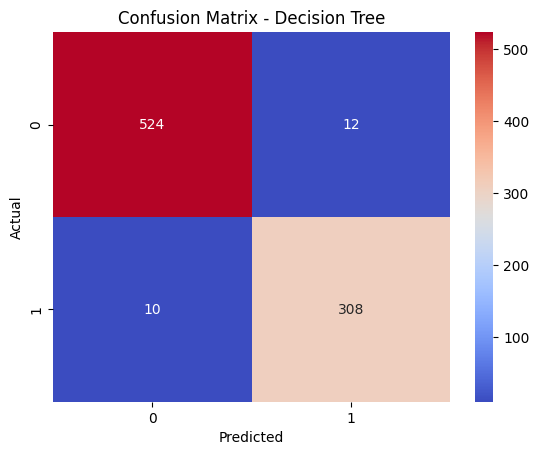

In [41]:
sns.heatmap(cm_dt,annot=True,fmt='d',cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

In [42]:
#random forest
cm_rf = confusion_matrix(Y_test,pred_rf)
print(cm_rf)

[[528   8]
 [ 10 308]]


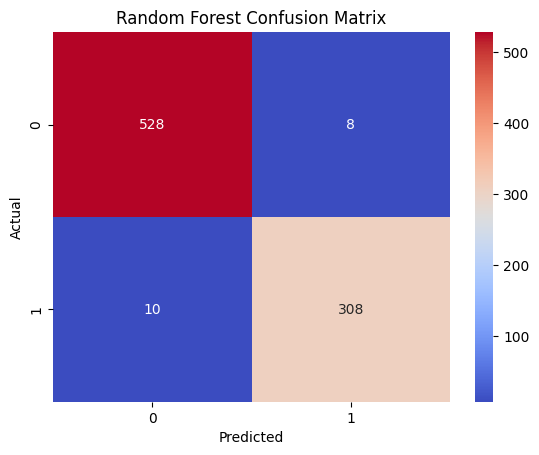

In [45]:
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [46]:
#svm
cm_svm = confusion_matrix(Y_test, pred_svm)
print(cm_svm)

[[502  34]
 [ 21 297]]


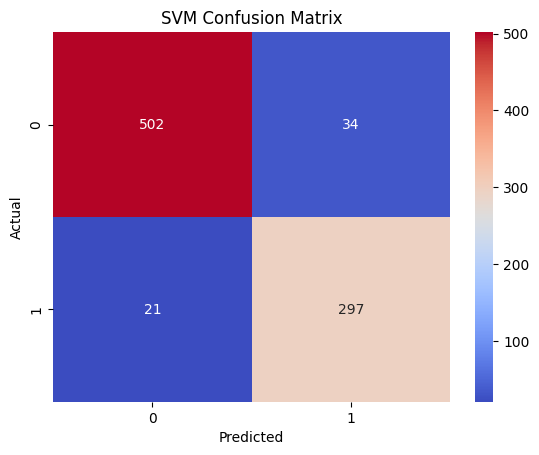

In [47]:
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

In [48]:
#classification report
#Desicion Tree
from sklearn.metrics import classification_report
print(classification_report(Y_test, pred_dt))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.96      0.97      0.97       318

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [49]:
#Random Forest
print(classification_report(Y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [50]:
#svm
print(classification_report(Y_test, pred_svm))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       536
           1       0.90      0.93      0.92       318

    accuracy                           0.94       854
   macro avg       0.93      0.94      0.93       854
weighted avg       0.94      0.94      0.94       854



In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
models = {
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "SVM": pred_svm
}
result = []

for name, pred in models.items():
  result.append([name, accuracy_score(Y_test, pred), precision_score(Y_test, pred), recall_score(Y_test, pred), f1_score(Y_test, pred)])

  comparison = pd.DataFrame(
      result,
      columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
  )
comparison = comparison.round(4)
print(comparison)

           Model  Accuracy  Precision  Recall  F1 Score
0  Decision Tree    0.9742     0.9625  0.9686    0.9655
1  Random Forest    0.9789     0.9747  0.9686    0.9716
2            SVM    0.9356     0.8973  0.9340    0.9153


In [53]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False)

feature_importance

,Feature,Importance
7,cibil_score,0.801838
6,loan_term,0.061950
5,loan_amount,0.027927
10,luxury_assets_value,0.016878
0,loan_id,0.016761
4,income_annum,0.016043
8,residential_assets_value,0.015732
11,bank_asset_value,0.015719
9,commercial_assets_value,0.015258
1,no_of_dependents,0.007455


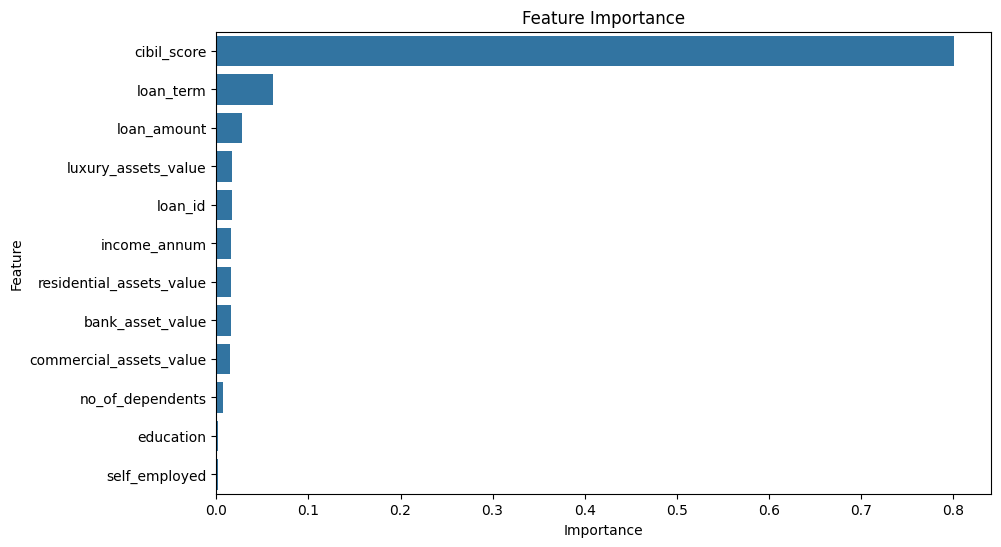

In [54]:
plt.figure(figsize=(10,6))

sns.barplot(data=feature_importance,
            x="Importance",
            y="Feature")

plt.title("Feature Importance")
plt.show()

The feature importance graph shows that CIBIL score, annual income, and loan amount are the most influential features in predicting loan approval. Features with higher importance contribute more to the model's decision-making process.

Random forest performed the best with an accuracy of 97.8% making it the most reliable model among the three

  CIBIL score, Income,Loan Amount,Residential Assets and Bank Assets have the highest impact on loan approval prediction

No. The model should be used as a decision support tool. Final approval should still be reviewed by loan officers to handle exceptional cases.

The model is trained only on historical data and may not generalize to future changes. It also depends on the quality and completeness of the dataset.

The model can be improved by using larger datasets, performing hyperparameter tuning, applying cross-validation, and testing advanced algorithms such as XGBoost or LightGBM.

#conclusion
This project developed a Loan Approval Prediction system using Decision Tree, Random Forest, and SVM algorithms. After preprocessing and evaluating the models, Random Forest achieved the highest accuracy of 97.89%, making it the best-performing model. The results show that CIBIL score, annual income, and asset values are the most influential factors in loan approval. This model can help EasyFinance automate the initial loan screening process, reduce manual effort, and support faster and more consistent decision-making.